### Doc2Vec
- Word2Vec의 확장판
- 기본적인 매개변수, 속성, 메서드는 Word2Vec와 같다.
- 추가적인 부분이 존재
- 매개변수
    - dm
        - 기본값 : 1
        - 학습 알고리즘을 선택
        - 1 : PV-DM
        - 0 : PV-DBOW
    - dm_mean
        - 기본값 : 0
        - 문장 벡터의 계산 방식 (PV-DM)
        - 0 : 벡터들의 합산, 범위가 커지는 경우가 발생 -> 노이즈로 인한 성능의 저하가 발생할 수 있다.
        - 1 : 벡터들의 평균
    - dm_concat
        - 기본값 : 0
        - PV-DM에서 문서 벡터와 문장 벡터를 결합할 것인가?
        - 결합을 하는 경우 차원이 급격하게 증가
    -dbow_words
        - 기본값 : 0
        - PV-DBOW 사용 시 단어 벡터도 동시에 학습할 것인가?
    - alpha | min_alpha
        - 기본값 : 0.025 | 0.0001
        - 보폭의 크기
        - 반복학습을 할 때 경사하강법의 기본적인 메뉴얼
        - 너무 크면 둔감, 너무 작으면 매우 민감해짐
- 속성
    - model.wv
        - 학습이 돈 단어 벡터의 저장소
        - PV-DBOW방식을 이용하고 dbow_words가 0인 경우 문서 벡터를 기준으로 단어 벡터를 생성 (단어 벡터를 학습으로 지정했을 떄랑 비교하면 신뢰도 떨어진다.)
    - model.dv
        - 학습이 된 문장 벡터의 저장소
    - model.dv.index_to_key
        - 문서들의 ID값의 리스트
- 메서드
    - build_vocab()
        - 단어 / 문서 사전을 구성
        - update 매개변수 : 기존 사전에 갱신을 할 것인가? (기본값 : False)
    - train()
        - 사전이 구축이 된 뒤 직접 학습을 수행
        - 기존에 학습이 된 모델에 train() 함수를 사용하게 되면 추가적인 학습이 진행
    - infer_vector()
        - 새로운 문장을 벡터화
        - 추가 학습이 아닌 학습이 된 모델로 문장 벡터를 되돌려준다.

- build_vocab(), train() 메서드를 이용하여 수동으로 학습을 설정
    - 기존의 학습된 모델에 fine-tunning(추가 학습)도 가능
- 일반적으로는 객체 생성시 sentences에 데이터를 추가적으로 학습 실행
- fine-tunning(증분 학습)을 사용하는 이유?
    - 데이터의 양이 증가하면 성능이 오를 수 있다.
    - 분할 학습을 통해서 시간을 나눠서 사용 가능
    - 기존의 학습 시킨 데이터와 유사한 데이터를 fine-tunning하여 성능을 향상


In [30]:
from konlpy.tag import Komoran
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import re

In [17]:
docs=[
    '#나는 커피를 정말 좋아한다',
    '오늘 아침에 에스프레소 두 잔을 마셨다',
    '카페라떼가 제일 맛있다고 생각한다',
    '나는 차를 더 자주 마신다',
    '녹차를 마시면 기분이 편안해진다',
    '홍차는 향이 깊고 고급스러운 느낌이다',
    '카페에서 책을 읽는 시간이 너무 좋다',
    '허브티도 몸에 좋은 거 같다'
]

In [ ]:
komoran=Komoran()

#특정 품사 사용
allow_pos=['NNP','NNG','VV','VA','MAG']
#불용어 처리
stop_word=['하다','되다','이다','것','수','거']

#문자에서 불필요한 글자들을 제거 (정규화)
def normalize(text):
    #특수 문자, 공백에 대한 처리
    text=re.sub(r'[^가-핳0-0a-xA-z\s\.]',' ',text)
    text=re.sub(r'\s+',' ',text).strip()
    return text

In [19]:
def tokenize(text):
    text=normalize(text)
    print(text)
    tokens=[]
    for word, pos in komoran.pos(text):
        if pos in allow_pos:
            #동사, 형용사에는 뒤에 '다'문자 추가
            if pos in ['VV','VA']:
                word += '다'
            if word not in stop_word and len(word)>1:
                tokens.append(word)
    return(tokens)

In [20]:
tokenize(docs[0])

나는 커피를 정말 좋아한다


['커피', '정말', '좋아하다']

In [21]:
tokenize_docs=[tokenize(doc) for doc in docs]
tokenize_docs

나는 커피를 정말 좋아한다
오늘 아침에 에스프레소 두 잔을 마셨다
카페라떼가 제일 맛있다고 생각한다
나는 차를 더 자주 마신다
녹차를 마시면 기분이 편안 진다
차는 이 깊고 고급스러운 느낌이다
카페에서 책을 읽는 시간이 너무 좋다
브티도 몸에 좋은 거 같다


[['커피', '정말', '좋아하다'],
 ['오늘', '아침', '에스프레소', '마시다'],
 ['카페', '제일', '맛있다', '생각'],
 ['자주', '마시다'],
 ['녹차', '마시다', '기분', '편안', '진다'],
 ['차다', '깊다', '고급', '느낌'],
 ['카페', '읽다', '시간', '너무', '좋다'],
 ['좋다', '같다']]

In [23]:
#doc2vec은 문장 하나씩에 ID를 붙여준다.
tagged=[]
for idx, token in enumerate(tokenize_docs):
    #idx : 위치
    #token : 리스트의 원소
    tagged.append(
        TaggedDocument(words=token, tags=[f'DOC_{idx}'])
    )
tagged

[TaggedDocument(words=['커피', '정말', '좋아하다'], tags=['DOC_0']),
 TaggedDocument(words=['오늘', '아침', '에스프레소', '마시다'], tags=['DOC_1']),
 TaggedDocument(words=['카페', '제일', '맛있다', '생각'], tags=['DOC_2']),
 TaggedDocument(words=['자주', '마시다'], tags=['DOC_3']),
 TaggedDocument(words=['녹차', '마시다', '기분', '편안', '진다'], tags=['DOC_4']),
 TaggedDocument(words=['차다', '깊다', '고급', '느낌'], tags=['DOC_5']),
 TaggedDocument(words=['카페', '읽다', '시간', '너무', '좋다'], tags=['DOC_6']),
 TaggedDocument(words=['좋다', '같다'], tags=['DOC_7'])]

In [51]:
model=Doc2Vec(
    documents=tagged,
    vector_size=100,
    window=3,
    min_count=1,
    dm=1,
    dm_mean=1,
    epochs=100,
    seed=42,
    negative=5  #잘못된 단어 배치를 사용하여 학습에서 이용
)

len(model.dv)

8

In [27]:
len(model.wv)

25

In [29]:
def print_similarities(doc_id):
    #입력받은 id 문장의 벡터 값
    dic_vec=model.dv[f'DOC_{doc_id}']

    #각각의 문장들의 벡터 데이터를 리스트로 생성
    mat=np.array(
        [model.dv[f'DOC_{i}'] for i in range(len(docs))]
    )

    #문장 벡터들을 dic_vec와 코사인 유사도를 구한다. 결과물이 2차원이지만 문장을 하나만 사용하면 1차원으로도 가능
    sims=cosine_similarity([dic_vec], mat)[0]

    order=sims.argsort()[::-1]

    #기존의 문장을 출력
    print(f'기존의 문장 : {doc_id} -> {docs[doc_id]}')
    for idx in order:
        print(f'    -> {idx} {docs[idx]}    |   cos = {sims[idx]}')

print_similarities(2)

기존의 문장 : 2 -> 카페라떼가 제일 맛있다고 생각한다
    -> 2 카페라떼가 제일 맛있다고 생각한다    |   cos = 0.9999998807907104
    -> 6 카페에서 책을 읽는 시간이 너무 좋다    |   cos = 0.2252623736858368
    -> 0 #나는 커피를 정말 좋아한다    |   cos = 0.12720774114131927
    -> 4 녹차를 마시면 기분이 편안해진다    |   cos = 0.11613627523183823
    -> 5 홍차는 향이 깊고 고급스러운 느낌이다    |   cos = 0.1106649786233902
    -> 1 오늘 아침에 에스프레소 두 잔을 마셨다    |   cos = 0.011591009795665741
    -> 7 허브티도 몸에 좋은 거 같다    |   cos = 8.155405521392822e-05
    -> 3 나는 차를 더 자주 마신다    |   cos = -0.18205341696739197


In [31]:
#고차원의 벡터 데이터를 그래프로 시각화하기 위해서 차원 축소 라이브러리 호출
from sklearn.manifold import TSNE

In [32]:
X=np.array(
    [model.dv[f'DOC_{idx}'] for idx in range(len(docs))]
)
X.shape

(8, 100)

In [36]:
tsne=TSNE(
    n_components=2,
    perplexity=5,
    random_state=42,
    max_iter=2000
)

In [37]:
X_2d=tsne.fit_transform(X)
X_2d.shape

(8, 2)

In [38]:
X_2d

array([[  38.377964,   91.17416 ],
       [-129.6469  ,   51.37626 ],
       [-114.625755,  -61.673035],
       [ 131.21889 ,   82.871254],
       [  64.40371 ,  -85.46495 ],
       [ -44.542538,   40.032837],
       [ -44.77635 ,  -90.42267 ],
       [  -2.698002,  -19.877808]], dtype=float32)

In [39]:
import matplotlib.pyplot as plt
import platform

In [40]:
#그래프에서 한글 깨짐 방지
if platform.system() == 'Darwin':
    plt.rc('font',family='AppleGothic')
else:
    plt.rc('font',family='Malgun Gothic')

#마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus']=False

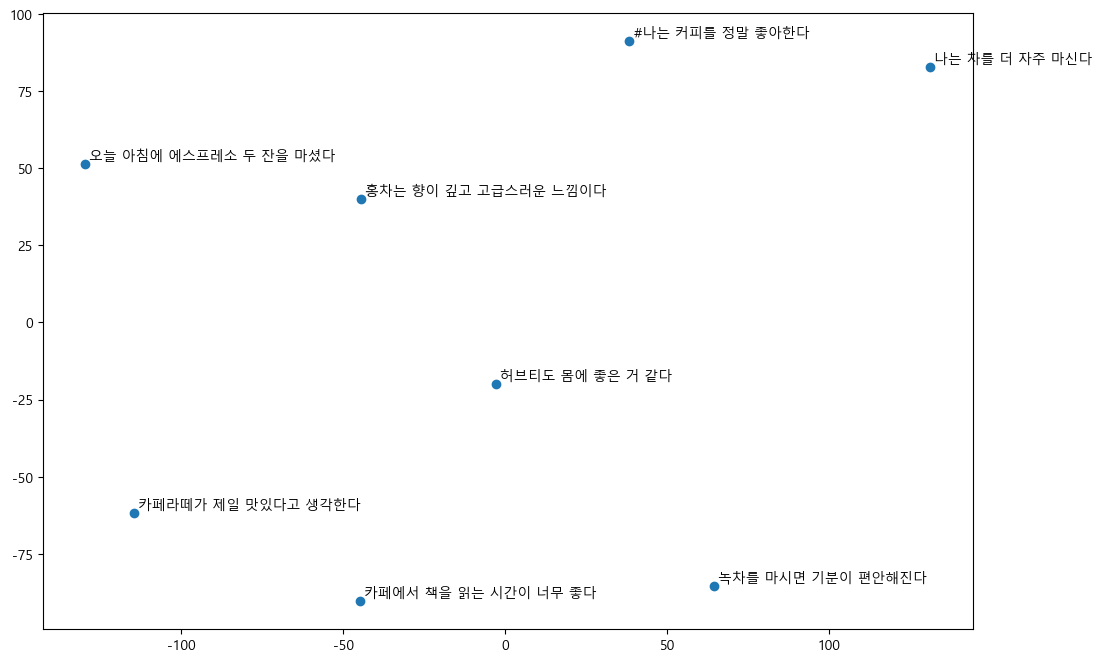

In [43]:
plt.figure(figsize=(12,8))

#산점도 그래프를 샌성
plt.scatter(
    X_2d[:,0], X_2d[:,1]
    )

#각각의 점에 주석을 달아주기
for idx, text in enumerate(docs):
    plt.annotate(
        text,
        xy=(X_2d[idx,0], X_2d[idx,1]),
        xytext=(3,3),
        textcoords='offset points'  #각각의 위치에 텍스트를 대입
    )

plt.show()

In [44]:
#문장 별 벡터의 값을 이용하여 ML 학습
#독립변수 : 문장 벡터
#종속 변수 : 커피(1), 논커피(0) 데이터를 생성
y=np.array([1,1,1,0,0,0,1,0])

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [47]:
X_train,X_test,y_train,y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [48]:
clf=LogisticRegression(random_state=42, max_iter=2000)
clf.fit(X_train,y_train),

(LogisticRegression(max_iter=2000, random_state=42),)

In [49]:
pred=clf.predict(X_test)
print(classification_report(pred,y_test))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.50      0.67         2

    accuracy                           0.50         2
   macro avg       0.50      0.25      0.33         2
weighted avg       1.00      0.50      0.67         2



c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c